# 4_3. SVC/SVM ręcznie: margines, support vectors, hard margin i soft margin

Najpierw rozróżnienie nazw:

- **SVM** (*Support Vector Machine*) — szersza idea: uczymy granicę z możliwie dużym marginesem.
- **SVC** (*Support Vector Classifier*) — praktyczny klasyfikator SVM do klasyfikacji.

Dla liniowego modelu decyzyjnego:

$$
f(x)=w^Tx+b.
$$

Predykcja:

$$
\hat y=\operatorname{sign}(f(x)).
$$

Granica decyzyjna to:

$$
f(x)=0.
$$

Linie marginesu to:

$$
f(x)=+1,\qquad f(x)=-1.
$$

### Jak dokładnie liczymy margines?

Dla wytrenowanego liniowego SVM liczymy:

```python
w = clf.coef_[0]
b = clf.intercept_[0]
f = clf.decision_function(X)   # to jest w^T x + b
```

Są trzy podobne, ale różne pojęcia:

| pojęcie | wzór | interpretacja |
|---|---:|---|
| wynik modelu | $f(x_i)=w^Tx_i+b$ | po której stronie granicy leży punkt |
| margines funkcyjny | $y_i f(x_i)$ | czy punkt jest dobrze sklasyfikowany i czy spełnia warunek marginesu |
| margines geometryczny | $\frac{y_i f(x_i)}{\lVert w\rVert}$ | odległość punktu od granicy, liczona po poprawnej stronie |

Odległość punktu od granicy $f(x)=0$ wynosi:

$$
\frac{|f(x_i)|}{\lVert w\rVert}.
$$

Odległość od granicy do jednej linii marginesu wynosi:

$$
\frac{1}{\lVert w\rVert},
$$

a szerokość całego pasa marginesu:

$$
\frac{2}{\lVert w\rVert}.
$$

To właśnie dlatego SVM minimalizuje $\frac{1}{2}\lVert w\rVert^2$: mniejsze $\lVert w\rVert$ oznacza szerszy margines.

## Uwaga organizacyjna

W tym notebooku **nie budujemy grafu** i **nie budujemy macierzy sąsiedztwa**.

SVM szuka granicy decyzyjnej maksymalizującej margines. Wersja liniowa szuka prostej w 2D, płaszczyzny w 3D albo hiperpłaszczyzny w większej liczbie wymiarów.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import plotly.graph_objects as go
from pathlib import Path

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## 1. Ręczny SVM w 1D: dwa punkty

Mamy dwa punkty:

$$
x_1=0,\quad y_1=-1,
$$

$$
x_2=2,\quad y_2=+1.
$$

Szukamy modelu:

$$
f(x)=wx+b.
$$

Dla support vectorów w twardym marginesie ustawiamy skalę tak, żeby:

$$
y_i(wx_i+b)=1.
$$

Dla punktu $x_1=0, y_1=-1$:

$$
-1\cdot(w\cdot 0+b)=1,
$$

czyli:

$$
b=-1.
$$

Dla punktu $x_2=2, y_2=+1$:

$$
1\cdot(2w+b)=1.
$$

Po podstawieniu $b=-1$:

$$
2w-1=1,
$$

więc:

$$
w=1.
$$

Czyli:

$$
f(x)=x-1.
$$

Granica decyzyjna:

$$
f(x)=0 \Rightarrow x=1.
$$

Linie marginesu:

$$
f(x)=-1 \Rightarrow x=0,
$$

$$
f(x)=+1 \Rightarrow x=2.
$$

Tutaj $\lVert w\rVert=1$, więc odległość od granicy do każdej linii marginesu to $1/\lVert w\rVert=1$, a cały margines ma szerokość $2/\lVert w\rVert=2$.

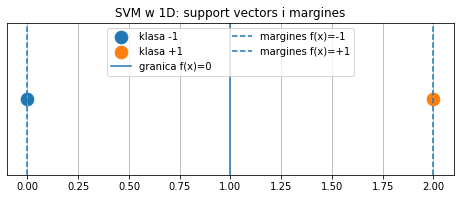

In [2]:
x_minus, x_plus = 0, 2
w, b = 1, -1
boundary = -b / w
margin_left = (-1 - b) / w
margin_right = (1 - b) / w

fig, ax = plt.subplots(figsize=(8,2.8))
ax.scatter([x_minus], [0], s=160, label='klasa -1')
ax.scatter([x_plus], [0], s=160, label='klasa +1')
ax.axvline(boundary, linestyle='-', label='granica f(x)=0')
ax.axvline(margin_left, linestyle='--', label='margines f(x)=-1')
ax.axvline(margin_right, linestyle='--', label='margines f(x)=+1')
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_title('SVM w 1D: support vectors i margines')
ax.legend(loc='upper center', ncol=2)
plt.show()

### Tabela kontrolna: marginesy w przykładzie 1D

Dla każdego punktu liczymy:

$$
f(x_i)=wx_i+b,
$$

$$
y_i f(x_i),
$$

oraz odległość geometryczną:

$$
\frac{y_i f(x_i)}{\lVert w\rVert}.
$$

W hard-margin support vectors mają $y_i f(x_i)=1$, czyli leżą dokładnie na liniach marginesu.

In [3]:
points_1d = pd.DataFrame({
    'x': [x_minus, x_plus],
    'y': [-1, 1],
})
points_1d['f(x)=w*x+b'] = w * points_1d['x'] + b
points_1d['y*f(x) margines funkcyjny'] = points_1d['y'] * points_1d['f(x)=w*x+b']
points_1d['y*f(x)/||w|| margines geometryczny'] = points_1d['y*f(x) margines funkcyjny'] / abs(w)
points_1d['odległość od granicy |f(x)|/||w||'] = points_1d['f(x)=w*x+b'].abs() / abs(w)
display(points_1d)

print('granica decyzyjna x =', boundary)
print('lewy margines f(x)=-1: x =', margin_left)
print('prawy margines f(x)=+1: x =', margin_right)
print('połowa szerokości marginesu 1/||w|| =', 1 / abs(w))
print('cała szerokość marginesu 2/||w|| =', 2 / abs(w))

,x,y,f(x)=w*x+b,y*f(x) margines funkcyjny,y*f(x)/||w|| margines geometryczny,odległość od granicy |f(x)|/||w||
0,0,-1,-1,1,1.0,1.0
1,2,1,1,1,1.0,1.0


granica decyzyjna x = 1.0
lewy margines f(x)=-1: x = 0.0
prawy margines f(x)=+1: x = 2.0
połowa szerokości marginesu 1/||w|| = 1.0
cała szerokość marginesu 2/||w|| = 2.0


## 2. Hard margin: granica bez błędów

Hard-margin SVM zakłada, że dane da się rozdzielić idealnie.

Problem optymalizacyjny:

$$
\min_{w,b}\frac{1}{2}\lVert w\rVert^2
$$

przy ograniczeniach:

$$
y_i(w^Tx_i+b)\geq 1.
$$

Jak czytać ograniczenie?

```text
y_i f(x_i) > 1   → punkt dobrze sklasyfikowany i poza marginesem
y_i f(x_i) = 1   → punkt leży na marginesie; typowy support vector
0 < y_i f(x_i) < 1 → punkt dobrze sklasyfikowany, ale wszedł do pasa marginesu
y_i f(x_i) < 0   → punkt jest błędnie sklasyfikowany
```

W hard margin nie dopuszczamy dwóch ostatnich przypadków. Dlatego hard margin jest dobry jako idea geometryczna, ale w realnych danych często jest zbyt sztywny.

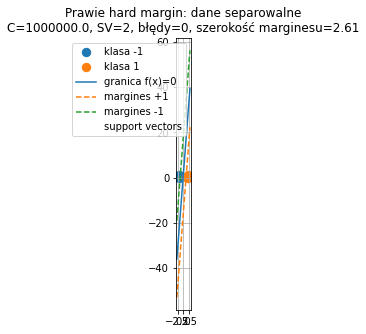

In [4]:
def plot_linear_svc(ax, X, y, C=1.0, title=''):
    clf = SVC(kernel='linear', C=C).fit(X, y)
    w = clf.coef_[0]
    b = clf.intercept_[0]
    xx = np.linspace(X[:,0].min()-0.8, X[:,0].max()+0.8, 200)
    def line(level):
        if abs(w[1]) < 1e-10:
            return np.full_like(xx, np.nan)
        return -(w[0]*xx + b - level)/w[1]
    for cls in [-1,1]:
        mask = y == cls
        ax.scatter(X[mask,0], X[mask,1], s=70, label=f'klasa {cls}')
    ax.plot(xx, line(0), label='granica f(x)=0')
    ax.plot(xx, line(1), linestyle='--', label='margines +1')
    ax.plot(xx, line(-1), linestyle='--', label='margines -1')
    ax.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1], s=160, facecolors='none', linewidths=2, label='support vectors')
    margin_width = 2 / np.linalg.norm(w)
    y_pred = clf.predict(X)
    errors = int(np.sum(y_pred != y))
    ax.set_title(f'{title}\nC={C}, SV={len(clf.support_)}, błędy={errors}, szerokość marginesu={margin_width:.2f}')
    ax.set_aspect('equal', adjustable='box')
    return clf, margin_width, errors

X_hard = np.array([[-2,0], [-2,1], [-1.3,0.4], [1.3,0.2], [2.0,1.0], [2.2,-0.2]])
y_hard = np.array([-1,-1,-1,1,1,1])
fig, ax = plt.subplots(figsize=(7,5))
plot_linear_svc(ax, X_hard, y_hard, C=1e6, title='Prawie hard margin: dane separowalne')
ax.legend(loc='best')
plt.show()

## 3. Soft margin i parametr $C$

W praktyce dane często mają szum albo punkty odstające. Wtedy wprowadzamy zmienne luzu $\xi_i$:

$$
y_i(w^Tx_i+b)\geq 1-\xi_i,
\qquad
\xi_i\geq 0.
$$

Soft-margin SVC rozwiązuje problem:

$$
\min_{w,b,\xi}
\frac{1}{2}\lVert w\rVert^2
+
C\sum_i \xi_i.
$$

To jest kompromis między dwiema rzeczami:

```text
1/2 ||w||^2       → chcemy szeroki margines
C * suma xi_i     → chcemy mało naruszeń marginesu i błędów
```

Parametr $C$ kontroluje karę za naruszenia:

```text
małe C  → naruszenia są tańsze, model może wybrać szerszy/gładszy margines,
duże C  → naruszenia są drogie, model mocniej próbuje dopasować się do danych.
```

Ważne: suwak $C$ **nie przesuwa ręcznie progu**. Dla każdej wartości $C$ model jest trenowany od nowa, więc zmieniają się jednocześnie:

- położenie granicy $f(x)=0$,
- szerokość marginesu $2/\lVert w\rVert$,
- liczba support vectors,
- liczba i wielkość naruszeń $\xi_i$.

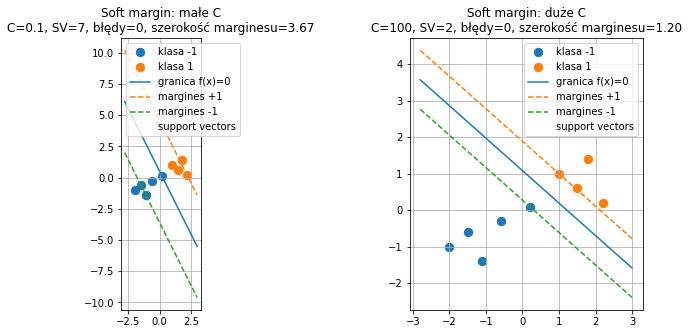

,C,liczba support vectors,błędy treningowe,szerokość marginesu 2/||w||
0,0.03,8,0,6.101
1,0.10,7,0,3.667
2,0.30,4,0,2.250
3,1.00,2,0,1.661
4,3.00,2,0,1.204
5,10.00,2,0,1.204
6,100.00,2,0,1.204


In [5]:
X_soft = np.array([
    [-2.0, -1.0], [-1.5, -0.6], [-1.1, -1.4], [-0.6, -0.3],
    [1.0, 1.0], [1.5, 0.6], [1.8, 1.4], [2.2, 0.2],
    [0.2, 0.1],  # trudny punkt blisko środka
])
y_soft = np.array([-1,-1,-1,-1, 1,1,1,1, -1])

fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_linear_svc(axes[0], X_soft, y_soft, C=0.1, title='Soft margin: małe C')
plot_linear_svc(axes[1], X_soft, y_soft, C=100, title='Soft margin: duże C')
for ax in axes:
    ax.legend(loc='best')
plt.show()

rows = []
for C in [0.03, 0.1, 0.3, 1, 3, 10, 100]:
    clf = SVC(kernel='linear', C=C).fit(X_soft, y_soft)
    wv = clf.coef_[0]
    margin_width = 2 / np.linalg.norm(wv)
    errors = int(np.sum(clf.predict(X_soft) != y_soft))
    rows.append({'C': C, 'liczba support vectors': len(clf.support_), 'błędy treningowe': errors, 'szerokość marginesu 2/||w||': round(margin_width, 3)})
display(pd.DataFrame(rows))

## 4. Jak liczymy naruszenia marginesu punkt po punkcie?

Po wytrenowaniu liniowego SVC mamy:

$$
f(x_i)=w^Tx_i+b.
$$

Dla każdej obserwacji liczymy margines funkcyjny:

$$
m_i = y_i f(x_i).
$$

Następnie zmienna luzu to:

$$
\xi_i = \max(0, 1-m_i)=\max(0, 1-y_i f(x_i)).
$$

Interpretacja:

| sytuacja | warunek | $\xi_i$ | znaczenie |
|---|---:|---:|---|
| poza marginesem, dobrze | $y_i f(x_i)>1$ | 0 | punkt nie psuje marginesu |
| na marginesie | $y_i f(x_i)=1$ | 0 | typowy support vector |
| wewnątrz marginesu, ale dobrze | $0<y_i f(x_i)<1$ | między 0 a 1 | punkt narusza margines |
| błędna klasyfikacja | $y_i f(x_i)<0$ | większe niż 1 | punkt jest po złej stronie granicy |

W tabeli niżej widać, które punkty faktycznie „kosztują” model w soft margin.

In [6]:
def margin_and_slack_table_for_C(X, y, C):
    clf = SVC(kernel='linear', C=C).fit(X, y)
    w_vec = clf.coef_[0]
    b_val = clf.intercept_[0]
    w_norm = np.linalg.norm(w_vec)

    f = clf.decision_function(X)                         # w^T x + b
    functional_margin = y * f                            # y_i f(x_i)
    geometric_margin = functional_margin / w_norm        # y_i f(x_i) / ||w||
    distance_to_boundary = np.abs(f) / w_norm            # |f(x_i)| / ||w||
    xi = np.maximum(0, 1 - functional_margin)            # slack variable
    pred = clf.predict(X)

    support_mask = np.zeros(len(X), dtype=bool)
    support_mask[clf.support_] = True

    status = np.select(
        [functional_margin < 0,
         (functional_margin >= 0) & (functional_margin < 1),
         np.isclose(functional_margin, 1, atol=1e-6),
         functional_margin > 1],
        ['błędnie sklasyfikowany', 'dobrze, ale w marginesie', 'na marginesie', 'dobrze poza marginesem'],
        default='inne'
    )

    table = pd.DataFrame({
        'x1': X[:, 0],
        'x2': X[:, 1],
        'y': y,
        'f(x)': f,
        'y*f(x) margines funkcyjny': functional_margin,
        'y*f(x)/||w|| margines geometryczny': geometric_margin,
        '|f(x)|/||w|| odległość od granicy': distance_to_boundary,
        'xi=max(0,1-y*f(x))': xi,
        'predykcja': pred,
        'status': status,
        'support vector?': np.where(support_mask, 'tak', 'nie'),
    })

    summary = pd.DataFrame({
        'C': [C],
        '||w||': [w_norm],
        'połowa marginesu 1/||w||': [1 / w_norm],
        'cała szerokość 2/||w||': [2 / w_norm],
        'suma xi': [xi.sum()],
        'liczba błędów': [np.sum(pred != y)],
        'liczba support vectors': [len(clf.support_)],
    })
    return summary.round(3), table.sort_values('xi=max(0,1-y*f(x))', ascending=False).round(3)

for C in [0.1, 100]:
    display(Markdown(f'### C = {C}'))
    summary, table = margin_and_slack_table_for_C(X_soft, y_soft, C)
    display(summary)
    display(table)

### C = 0.1

,C,||w||,połowa marginesu 1/||w||,cała szerokość 2/||w||,suma xi,liczba błędów,liczba support vectors
0,0.1,0.545,1.834,3.667,2.146,0,7


,x1,x2,y,f(x),y*f(x) margines funkcyjny,y*f(x)/||w|| margines geometryczny,|f(x)|/||w|| odległość od granicy,"xi=max(0,1-y*f(x))",predykcja,status,support vector?
8,0.2,0.1,-1,-0.000,0.000,0.000,0.000,1.000,-1,"dobrze, ale w marginesie",tak
3,-0.6,-0.3,-1,-0.488,0.488,0.894,0.894,0.512,-1,"dobrze, ale w marginesie",tak
4,1.0,1.0,1,0.610,0.610,1.118,1.118,0.390,1,"dobrze, ale w marginesie",tak
5,1.5,0.6,1,0.756,0.756,1.386,1.386,0.244,1,"dobrze, ale w marginesie",tak
2,-1.1,-1.4,-1,-1.000,1.000,1.834,1.834,0.000,-1,"dobrze, ale w marginesie",tak
0,-2.0,-1.0,-1,-1.341,1.341,2.460,2.460,0.000,-1,dobrze poza marginesem,nie
1,-1.5,-0.6,-1,-1.000,1.000,1.834,1.834,0.000,-1,dobrze poza marginesem,tak
6,1.8,1.4,1,1.098,1.098,2.012,2.012,0.000,1,dobrze poza marginesem,nie
7,2.2,0.2,1,1.000,1.000,1.834,1.834,0.000,1,dobrze poza marginesem,tak


### C = 100

,C,||w||,połowa marginesu 1/||w||,cała szerokość 2/||w||,suma xi,liczba błędów,liczba support vectors
0,100,1.661,0.602,1.204,0.0,0,2


,x1,x2,y,f(x),y*f(x) margines funkcyjny,y*f(x)/||w|| margines geometryczny,|f(x)|/||w|| odległość od granicy,"xi=max(0,1-y*f(x))",predykcja,status,support vector?
0,-2.0,-1.0,-1,-4.793,4.793,2.886,2.886,0.0,-1,dobrze poza marginesem,nie
1,-1.5,-0.6,-1,-3.745,3.745,2.255,2.255,0.0,-1,dobrze poza marginesem,nie
2,-1.1,-1.4,-1,-4.297,4.297,2.587,2.587,0.0,-1,dobrze poza marginesem,nie
3,-0.6,-0.3,-1,-2.379,2.379,1.433,1.433,0.0,-1,dobrze poza marginesem,nie
4,1.0,1.0,1,1.000,1.000,0.602,0.602,0.0,1,na marginesie,tak
5,1.5,0.6,1,1.055,1.055,0.635,0.635,0.0,1,dobrze poza marginesem,nie
6,1.8,1.4,1,2.379,2.379,1.433,1.433,0.0,1,dobrze poza marginesem,nie
7,2.2,0.2,1,1.331,1.331,0.801,0.801,0.0,1,dobrze poza marginesem,nie
8,0.2,0.1,-1,-1.000,1.000,0.602,0.602,0.0,-1,na marginesie,tak


## 5. Macierz pomyłek a margines — to nie jest to samo

SVC jest klasyfikatorem, więc możemy policzyć macierz pomyłek. Trzeba jednak uważać: **macierz pomyłek nie pokazuje marginesów**.

Macierz pomyłek odpowiada tylko na pytanie:

```text
czy przewidziana klasa jest taka sama jak prawdziwa klasa?
```

SVM patrzy na coś bogatszego:

```text
czy punkt jest po dobrej stronie granicy?
czy punkt jest poza marginesem?
czy punkt narusza margines i jak bardzo?
```

Dlatego punkt może być poprawnie sklasyfikowany, a mimo to mieć dodatnie $\xi_i$, bo znajduje się wewnątrz pasa marginesu.

,pred -1,pred +1
true -1,5,0
true +1,0,4


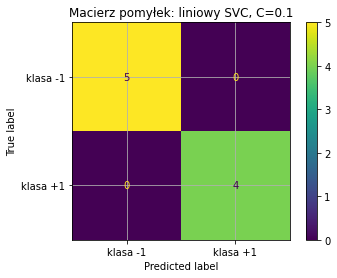

,pred -1,pred +1
true -1,5,0
true +1,0,4


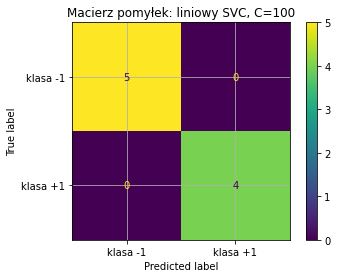

,C,accuracy treningowa,liczba błędów w confusion matrix,suma naruszeń marginesu sum(xi),liczba punktów z xi > 0,liczba support vectors
0,0.1,1.0,0,2.146,5,7
1,100.0,1.0,0,0.000,0,2


In [7]:
summary_rows = []
for C in [0.1, 100]:
    clf = SVC(kernel='linear', C=C).fit(X_soft, y_soft)
    pred = clf.predict(X_soft)
    f = clf.decision_function(X_soft)
    xi = np.maximum(0, 1 - y_soft * f)
    cm = confusion_matrix(y_soft, pred, labels=[-1, 1])
    summary_rows.append({
        'C': C,
        'accuracy treningowa': accuracy_score(y_soft, pred),
        'liczba błędów w confusion matrix': int(np.sum(pred != y_soft)),
        'suma naruszeń marginesu sum(xi)': xi.sum(),
        'liczba punktów z xi > 0': int(np.sum(xi > 1e-8)),
        'liczba support vectors': len(clf.support_),
    })
    display(pd.DataFrame(cm, index=['true -1', 'true +1'], columns=['pred -1', 'pred +1']).style.set_caption(f'C = {C}'))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['klasa -1', 'klasa +1']).plot()
    plt.title(f'Macierz pomyłek: liniowy SVC, C={C}')
    plt.show()

display(pd.DataFrame(summary_rows).round(3))

## 6. Interaktywny suwak $C$

Na wykresie obserwuj trzy rzeczy:

1. położenie granicy decyzyjnej $f(x)=0$,
2. szerokość marginesu $2/\lVert w\rVert$,
3. liczbę support vectors i punkty wewnątrz pasa marginesu.

Interpretacja:

```text
C małe  → miękki margines, więcej tolerancji, często więcej support vectors.
C duże  → bardziej surowy margines, mniej tolerancji, większe ryzyko przeuczenia.
```

Hard margin można traktować jako graniczny przypadek soft margin, gdy dane są separowalne i $C$ jest bardzo duże.

Panel jest zapisany także do pliku HTML, ale w notebooku powinien wyświetlić się bezpośrednio po wykonaniu komórki.

In [9]:
def svc_frame_data(X, y, C):
    clf = SVC(kernel='linear', C=C).fit(X, y)
    w = clf.coef_[0]
    b = clf.intercept_[0]
    xx = np.linspace(X[:,0].min()-0.8, X[:,0].max()+0.8, 200)
    def yy(level):
        if abs(w[1]) < 1e-10:
            return np.full_like(xx, np.nan)
        return -(w[0]*xx + b - level)/w[1]
    margin_width = 2 / np.linalg.norm(w)
    errors = int(np.sum(clf.predict(X) != y))
    return clf, xx, yy(0), yy(1), yy(-1), margin_width, errors

C_values = [0.03, 0.1, 0.3, 1, 3, 10, 100]
# Dane punktowe
fig = go.Figure()
mask_neg = y_soft == -1
mask_pos = y_soft == 1
fig.add_trace(go.Scatter(x=X_soft[mask_neg,0], y=X_soft[mask_neg,1], mode='markers', name='klasa -1'))
fig.add_trace(go.Scatter(x=X_soft[mask_pos,0], y=X_soft[mask_pos,1], mode='markers', name='klasa +1'))

# Dodajemy traces dla każdego C, potem suwakiem włączamy tylko właściwy zestaw.
visible_base = [True, True]
all_infos = []
for idx, C in enumerate(C_values):
    clf, xx, y0, yp, ym, margin_width, errors = svc_frame_data(X_soft, y_soft, C)
    all_infos.append((clf, margin_width, errors))
    visible = (idx == 1)  # domyślnie C=0.1
    fig.add_trace(go.Scatter(x=xx, y=y0, mode='lines', name=f'granica C={C}', visible=visible))
    fig.add_trace(go.Scatter(x=xx, y=yp, mode='lines', line=dict(dash='dash'), name='margines +1', visible=visible))
    fig.add_trace(go.Scatter(x=xx, y=ym, mode='lines', line=dict(dash='dash'), name='margines -1', visible=visible))
    fig.add_trace(go.Scatter(x=clf.support_vectors_[:,0], y=clf.support_vectors_[:,1], mode='markers',
                             marker=dict(size=15, symbol='circle-open', line=dict(width=2)),
                             name='support vectors', visible=visible))

steps = []
for idx, C in enumerate(C_values):
    vis = [True, True] + [False] * (4 * len(C_values))
    base = 2 + 4*idx
    for j in range(4):
        vis[base+j] = True
    clf, margin_width, errors = all_infos[idx]
    steps.append(dict(
        method='update',
        args=[{'visible': vis},
              {'title': f'Liniowy SVC: C={C}, support vectors={len(clf.support_)}, błędy={errors}, szerokość marginesu={margin_width:.2f}'}],
        label=str(C)
    ))

fig.update_layout(
    title='Liniowy SVC: suwak C',
    xaxis_title='x1', yaxis_title='x2',
    sliders=[dict(active=1, currentvalue={'prefix':'C = '}, steps=steps)]
)
# Zapisujemy też osobny plik HTML, gdyby notebook nie renderował suwaka.
out_html = Path('../html/4_3_svc_svm_suwak_C_interaktywny_v3.html')
out_html.parent.mkdir(parents=True, exist_ok=True)
try:
    fig.write_html(out_html, include_plotlyjs='cdn')
    print(f'Zapisano interaktywny wykres do: {out_html}')
except Exception as e:
    print('Nie udało się zapisać HTML:', e)

print('Interaktywny wykres zapisano jako HTML. W Jupyter można odkomentować fig.show(), żeby zobaczyć suwak inline.')
# fig.show()

Zapisano interaktywny wykres do: ../html/4_3_svc_svm_suwak_C_interaktywny_v3.html
Interaktywny wykres zapisano jako HTML. W Jupyter można odkomentować fig.show(), żeby zobaczyć suwak inline.


## 7. Co zapamiętać?

- **Granica decyzyjna** to $f(x)=0$.
- **Linie marginesu** to $f(x)=+1$ i $f(x)=-1$.
- **Odległość punktu od granicy** to $|f(x)|/\lVert w\rVert$.
- **Margines funkcyjny** to $y_i f(x_i)$; mówi, czy punkt spełnia warunek $y_i f(x_i)\geq 1$.
- **Szerokość całego marginesu** to $2/\lVert w\rVert$.
- **Slack variable** to $\xi_i=\max(0,1-y_i f(x_i))$.
- **Support vectors** to punkty, które leżą na marginesie albo go naruszają; to one najmocniej wyznaczają granicę.
- **Macierz pomyłek** pokazuje błędy klasyfikacji, ale nie pokazuje naruszeń marginesu; do tego służy tabela z $y_i f(x_i)$ i $\xi_i$.
- **Małe $C$** daje więcej tolerancji na naruszenia. **Duże $C$** mocniej karze naruszenia i może prowadzić do ciaśniejszego dopasowania.

W następnym notebooku zobaczymy, co zrobić, gdy żadna prosta nie wystarcza: wtedy używamy kerneli.